# Análise dos Resultados

Requer `previsoes_consolidadas.csv` gerado por `02_modelos.R` (M0, M1, M2, painel alinhado).

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from arch.bootstrap import MCS
from datetime import datetime

CAMINHO = "./data/"


In [40]:
# ── Carrega dados ────────────────────────────────────────────────
df_acoes        = pd.read_csv(CAMINHO + "acoes_elegiveis.csv")
df_trends       = pd.read_csv(CAMINHO + "google_trends_svi.csv",     parse_dates=["semana"])
df_final        = pd.read_csv(CAMINHO + "base_final_tcc.csv",        parse_dates=["semana"])

df_previsoes    = pd.read_csv(CAMINHO + "previsoes_consolidadas.csv", parse_dates=["semana"])
df_resumo_params = pd.read_csv(CAMINHO + "resumo_parametros.csv").set_index("ticker_b3")

# ── Proporção de zeros no SVI ─────────────────────────────────────
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
df_resumo_params["svi_zeros_pct"] = zeros_pct.reindex(df_resumo_params.index)
tickers_erro_m2 = df_previsoes[(df_previsoes["status_m2"] != "ok") | (df_previsoes['rv_pred_m2'] == np.inf)]["ticker_b3"].unique()

In [39]:
df_previsoes[(df_previsoes["status_m2"] != "ok") | (df_previsoes['rv_pred_m2'] == np.inf)]["ticker_b3"].unique()

<StringArray>
[ 'AFLT3',  'AHEB3',  'ALUP3',  'AXIA3',  'AXIA6',  'AZZA3',  'BALM4',
  'BDLL4',  'BMEB3',  'BNBR3',  'BPAC5',  'BRSR3',  'BRSR5',  'CBEE3',
  'CEDO3',  'CEEB3',  'CGAS5',  'CGRA3',  'CLSC4',  'DEXP4',  'DOHL4',
  'EALT3', 'EQMA3B',  'EQPA3',  'FRAS3',  'GEPA4',  'GSHP3',  'HBTS5',
  'ISAE3',  'ISAE4',  'LUXM4',  'MBRF3',  'MNDL3', 'MRSA3B',  'PATI4',
  'PEAB3',  'PLAS3', 'PPLA11',  'PTNT4',  'REDE3',  'RPAD3',  'RPAD5',
  'TKNO4',  'WHRL3',  'WHRL4']
Length: 45, dtype: str

# Testes qlike e MCS

In [46]:
# ── QLIKE loss ───────────────────────────────────────────────────
def qlike(rv, pred):
    """QLIKE: rv/pred - log(rv/pred) - 1. NaN onde rv ou pred <= 0."""
    ok = (rv > 0) & (pred > 0)
    r  = np.where(ok, rv / pred, np.nan)
    return np.where(ok, r - np.log(r) - 1, np.nan)

NOMES_MODELOS = {
    "qlike_m0": "M0_RW",
    "qlike_m1": "M1_GARCH",
    "qlike_m2": "M2_GARCHX",
}

# Piso minimo para previsoes GARCH/EGARCH. Valores abaixo (ou inf/NaN)
# indicam falha numerica do ajuste: o log-variance do EGARCH pode driftar
# sem ser capturado pelo status do hessiano, gerando QLIKE astronomico
# que quebra o MCS. Aplica-se apenas a M1/M2; M0 (RW) so propaga RV
# observada, entao valores pequenos sao dado real, nao falha de modelo.
PRED_MIN = 1e-8

def filtrar_tickers(df, zeros_pct, threshold_zeros=None, remove_singular=True):
    """Filtra tickers para a comparacao de modelos.

    Dois conjuntos de tickers problematicos sao identificados:
      * patologicos : algum rv_pred_m1/m2 nao-finito ou < PRED_MIN
        (falha numerica do GARCH/EGARCH) -> SEMPRE descartados.
      * singulares  : status_m2 != 'ok' (hessiana singular / warning do
        rugarch) -> descartados apenas se remove_singular=True.

    Retorna (df_filtrado, info_dict com contagens para relatorio).
    """
    pred_cols = ["rv_pred_m1", "rv_pred_m2"]
    preds = df[pred_cols].to_numpy()
    rows_ok = np.all(np.isfinite(preds) & (preds >= PRED_MIN), axis=1)
    tickers_pat  = set(df.loc[~rows_ok, "ticker_b3"].unique())
    tickers_sing = set(df.loc[df["status_m2"] != "ok", "ticker_b3"].unique())
    tickers_erro = tickers_pat | tickers_sing

    info = {
        "n_total":     df["ticker_b3"].nunique(),
        "n_patologic": len(tickers_pat),
        "n_singular":  len(tickers_sing),
        "n_erros":     len(tickers_erro),
    }

    # Sempre descarta tickers com previsoes patologicas
    df = df[~df["ticker_b3"].isin(tickers_pat)]

    if threshold_zeros is not None:
        ok = zeros_pct[zeros_pct < threshold_zeros].index
        df = df[df["ticker_b3"].isin(ok)]
        info["n_apos_zeros"]    = df["ticker_b3"].nunique()
        info["erros_apos_zeros"] = df[df["ticker_b3"].isin(tickers_erro)]["ticker_b3"].nunique()

    if remove_singular:
        df = df[~df["ticker_b3"].isin(tickers_sing)]

    info["n_final"] = df["ticker_b3"].nunique()
    return df, info


def calcular_losses(df):
    """Calcula QLIKE por modelo. Retorna (losses sem NaN, n_descartadas)."""
    df = df.copy()
    for m in ["m0", "m1", "m2"]:
        df[f"qlike_{m}"] = qlike(df["rv"].values, df[f"rv_pred_{m}"].values)

    losses = (
        df[list(NOMES_MODELOS)]
        .dropna()
        .rename(columns=NOMES_MODELOS)
        .reset_index(drop=True)
    )
    return losses, len(df) - len(losses)


def rodar_mcs(losses, alpha=0.10):
    """Model Confidence Set. Retorna (mcs_obj, df_pvalores)."""
    mcs = MCS(losses, size=alpha, block_size=5, reps=1000, seed=42)
    mcs.compute()
    df_p = (
        mcs.pvalues
        .rename(columns={"Pvalue": "p_valor"})
        .assign(no_conjunto=lambda d: d["p_valor"] >= alpha)
        .sort_values("p_valor", ascending=False)
    )
    return mcs, df_p


def resumo_gamma(df_resumo, tickers):
    """Conta tickers com gamma significativo em >=50% das janelas."""
    df    = df_resumo.loc[df_resumo.index.isin(tickers)]
    n_sig = int((df["pct_signif_5pct"] >= 50).sum())
    top5  = df["pct_signif_5pct"].sort_values(ascending=False).head(5)
    return n_sig, top5


def gerar_bloco(df_prev, df_resumo, zeros_pct,
                threshold_zeros=None, remove_singular=True, label=""):
    """Gera bloco de texto com diagnostico para um cenario de filtragem."""
    df, info       = filtrar_tickers(df_prev, zeros_pct, threshold_zeros, remove_singular)
    tickers_finais = set(df["ticker_b3"].unique())
    losses, n_desc = calcular_losses(df)
    mcs, df_pval   = rodar_mcs(losses)
    n_sig, top5    = resumo_gamma(df_resumo, tickers_finais)

    # Formata texto
    sep = "═" * 60
    L   = [f"\n{sep}", f"  {label}", sep]

    L.append(f"  Tickers em df_previsoes              : {info['n_total']}")
    L.append(f"  Com erro (M2)                        : {info['n_erros']}")
    if threshold_zeros is not None:
        pct = int(threshold_zeros * 100)
        L.append(f"  Apos filtro zeros >={pct}%              : {info['n_apos_zeros']}  ({info['erros_apos_zeros']} com erro)")
    L.append(f"  Na comparacao final                  : {info['n_final']}")
    L.append(f"  Obs. OOS usadas / descartadas        : {len(losses)} / {n_desc}")

    L.append("\n  QLIKE medio:")
    for col in losses.columns:
        L.append(f"    {col:<15}: {losses[col].mean():.6f}")

    L.append("\n  MCS (alpha=10%):")
    for line in df_pval.to_string().split("\n"):
        L.append(f"    {line}")
    L.append(f"\n  Conjunto de confianca : {list(mcs.included)}")
    L.append(f"  Excluidos             : {list(mcs.excluded)}")

    L.append(f"\n  gamma significativo em >=50% das janelas:")
    L.append(f"    {n_sig}/{info['n_final']} tickers")
    L.append("\n  Top 5 por % de janelas significativas (gamma):")
    L.append(top5.to_string())

    return "\n".join(L) + "\n"

In [48]:
# ── Gera diagnostico ─────────────────────────────────────────────
cenarios = [
    # (threshold, remove_singular_matrix, label)
    (None, False, "1. Considerando todos os ativo"),
    (None, True, "1.b. Considerando todos os ativo, filtrando erro hessiana"),
    (0.70, True,  "2. Filtro >=70%"),
    (0.50, True,  "3. Filtro >=50%"),
]

TXT = "/diagnostico_filtros.txt"
with open(f"{CAMINHO}{TXT}", "w", encoding="utf-8") as f:
    f.write("Diagnostico - comparacao de cenarios\n")
    f.write(f"Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    for threshold, remove_sing, label in cenarios:
        bloco = gerar_bloco(df_previsoes, df_resumo_params, zeros_pct,
                            threshold, remove_sing, label)
        f.write(bloco)

print(f"✓ Salvo em {TXT}")

✓ Salvo em /diagnostico_filtros.txt


In [ ]:
# ── Salvar QLIKE por ticker e MCS (todos os ativos) ──────────────
# Filtra apenas tickers com erro de singular matrix no M2
df_ok, info = filtrar_tickers(df_previsoes, zeros_pct,
                              threshold_zeros=None, remove_singular=False)

# Calcula QLIKE por observacao
df_ok = df_ok.copy()
for m in ["m0", "m1", "m2"]:
    df_ok[f"qlike_{m}"] = qlike(df_ok["rv"].values, df_ok[f"rv_pred_{m}"].values)

# QLIKE medio por ticker
df_qlike = (
    df_ok.groupby("ticker_b3")[list(NOMES_MODELOS)]
    .mean()
    .rename(columns=NOMES_MODELOS)
)

# MCS no agregado (pooled)
losses, n_desc = calcular_losses(df_ok)
mcs, df_mcs_principal = rodar_mcs(losses, alpha=0.10)

# Salva CSVs
df_qlike.to_csv(CAMINHO + "qlike_por_ticker.csv")
df_mcs_principal.to_csv(CAMINHO + "mcs_resultado.csv")

## Diagnósticos dos Resíduos Padronizados

Resultados de Ljung-Box em $z_t$ e $z_t^2$, Jarque-Bera e Q-Q plot para o
Top 5 de tickers ranqueados por `pct_signif_5pct` (significância de γ no M2).

In [28]:
df_diag = pd.read_csv(CAMINHO + "diagnosticos_residuos.csv")
df_z    = pd.read_csv(CAMINHO + "residuos_padronizados.csv")

tab = (
    df_diag
    .assign(ticker_b3=lambda d: pd.Categorical(d["ticker_b3"], ordered=True))
    .sort_values(["ticker_b3", "modelo"])
    [["ticker_b3", "modelo", "assimetria", "curtose",
      "lb_z_pvalor", "lb_z2_pvalor", "jb_pvalor"]]
    .round(4)
)
print(tab.to_string(index=False))

ticker_b3 modelo  assimetria  curtose  lb_z_pvalor  lb_z2_pvalor  jb_pvalor
    AALR3     m1     -1.3867   8.5826       0.4915        0.9757     0.0000
    AALR3     m2     -1.1809   7.4981       0.4663        0.9220     0.0000
    ABCB4     m1      0.5867   3.4703       0.8456        0.9672     0.0056
    ABCB4     m2      0.4571   2.8555       0.8292        0.9331     0.0618
    ABEV3     m1      0.5146   4.5208       0.5152        0.6692     0.0000
    ABEV3     m2      0.2509   3.7536       0.3608        0.4470     0.0696
    AERI3     m1      0.7118   8.8599       0.8000        0.9879     0.0000
    AERI3     m2      0.7397   7.1108       0.8430        0.9669     0.0000
    AFLT3     m1      0.2368   5.1715       0.1916        0.8760     0.0000
    AFLT3     m2      0.2064   5.3706       0.1133        0.8226     0.0000
    AGRO3     m1      0.3745   3.2059       0.2248        0.2296     0.1408
    AGRO3     m2      0.1318   3.1198       0.1346        0.1691     0.7616
    AHEB3   

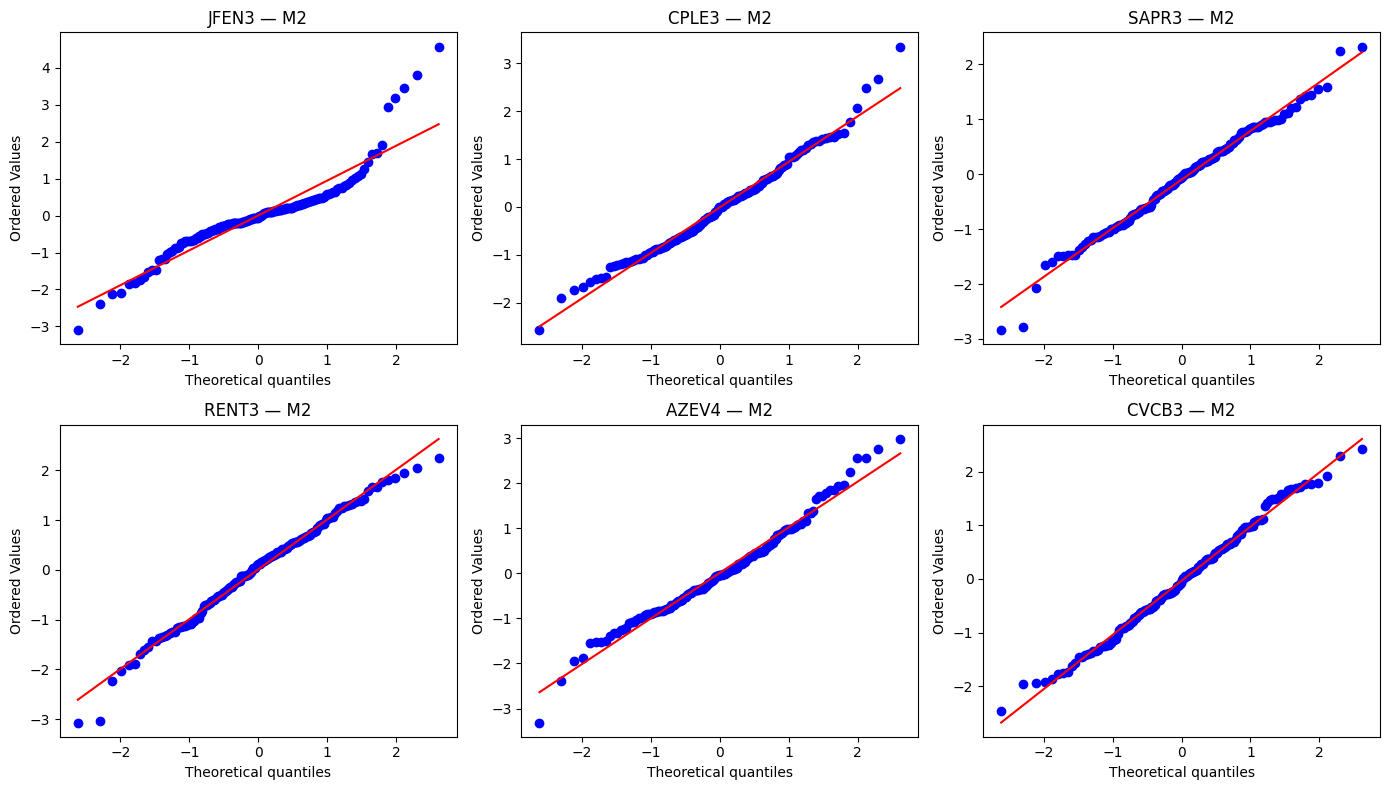

In [29]:
top_tickers = ["JFEN3","CPLE3","SAPR3","RENT3","AZEV4","CVCB3"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, tk in zip(axes.flat, top_tickers):
    z = df_z.query("ticker_b3 == @tk and modelo == 'm2'")["z"].values
    stats.probplot(z, dist="norm", plot=ax)
    ax.set_title(f"{tk} — M2")
plt.tight_layout()
plt.show()

# Outras coisas

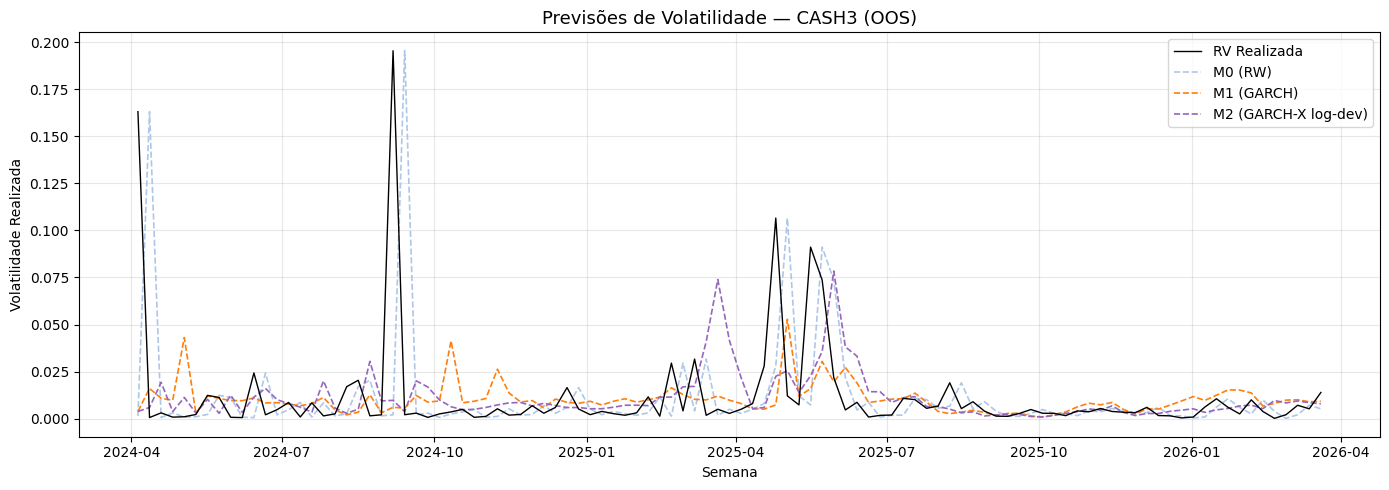

In [50]:
# ── Gráfico comparando as previsões ────────────────────────────────────────────────
TICKER = "CASH3" 

df_graf = (
    df_previsoes
    .query("ticker_b3 == @TICKER")
    .sort_values("semana")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_graf["semana"], df_graf["rv"],         label="RV Realizada", color="black",   linewidth=1.0, zorder=5)
ax.plot(df_graf["semana"], df_graf["rv_pred_m0"], label="M0 (RW)",      color="#aec7e8", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m1"], label="M1 (GARCH)",   color="#ff7f0e", linewidth=1.2, linestyle="--")
ax.plot(df_graf["semana"], df_graf["rv_pred_m2"], label="M2 (GARCH-X log-dev)", color="#9467bd", linewidth=1.2, linestyle="--")

ax.set_title(f"Previsões de Volatilidade — {TICKER} (OOS)", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Volatilidade Realizada")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_qlike = pd.read_csv(CAMINHO + "qlike_por_ticker.csv")

df_qlike["melhor"] = df_qlike[list(NOMES_MODELOS.values())].idxmin(axis=1)
print(df_qlike["melhor"].value_counts())

In [ ]:
float_cols = df_resumo_params.select_dtypes(include="float").columns
df_resumo_params[float_cols] = df_resumo_params[float_cols].round(4)
df_resumo_params.to_csv(CAMINHO + "apendice_resumo_params.csv")

df_resumo_params

In [ ]:
TICKERS = ["PINE4", "DASA3", "CPLE3", "SAPR11", "PETR4"]
df_resumo_params.query("ticker_b3 in @TICKERS")

In [ ]:
TICKER = "PETR4"
df_previsoes.query("ticker_b3 == @TICKER").sort_values("semana")

In [ ]:
df_previsoes["iguais"] = round(df_previsoes["rv_pred_m1"], 6) == round(df_previsoes["rv_pred_m2"], 6)
df_previsoes[df_previsoes["iguais"] == True]

In [ ]:
temp = df_previsoes.pivot_table(index="ticker_b3", columns="status_m2",values="semana", aggfunc="count").fillna(0).astype(int)

print(len(temp))
len(temp.query("ok != 103")) + len(temp.query("ok == 103"))